# **Atmospheric Sensitivity to Solar Forcing Mini-project using SpeedyWeather.jl**

**Understanding how solar variability impacts climate is an important part of Sun–Earth connection research.**

# **Julia**

In [ ]:
using Pkg
Pkg.add("IJulia")




   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [ ]:
Pkg.add("SpeedyWeather")
Pkg.add("GeoMakie")
Pkg.add("CairoMakie")
Pkg.add("NCDatasets")

#GeoMakie.jl is a Julia package for plotting geospatial data on a given map projection. It is built on top of the Makie.jl plotting ecosystem.
#CairoMakie uses Cairo.jl to draw vector graphics to SVG and PDF. Use it to achieve the highest-quality plots for publications.

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [ ]:
# Check set up

using SpeedyWeather
using GeoMakie, CairoMakie
using Statistics

# **1. Baseline Atmospheric Temperature Distribution**

**Global near-surface temperature under standard solar forcing (control simulation)**

 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:01:14 (2000-04-10, 316.71 years/day, 94 m/s, [-75, 33] ˚C)


Simulation complete!
Temperature size: (3168,)
Mean temperature: 280.31744


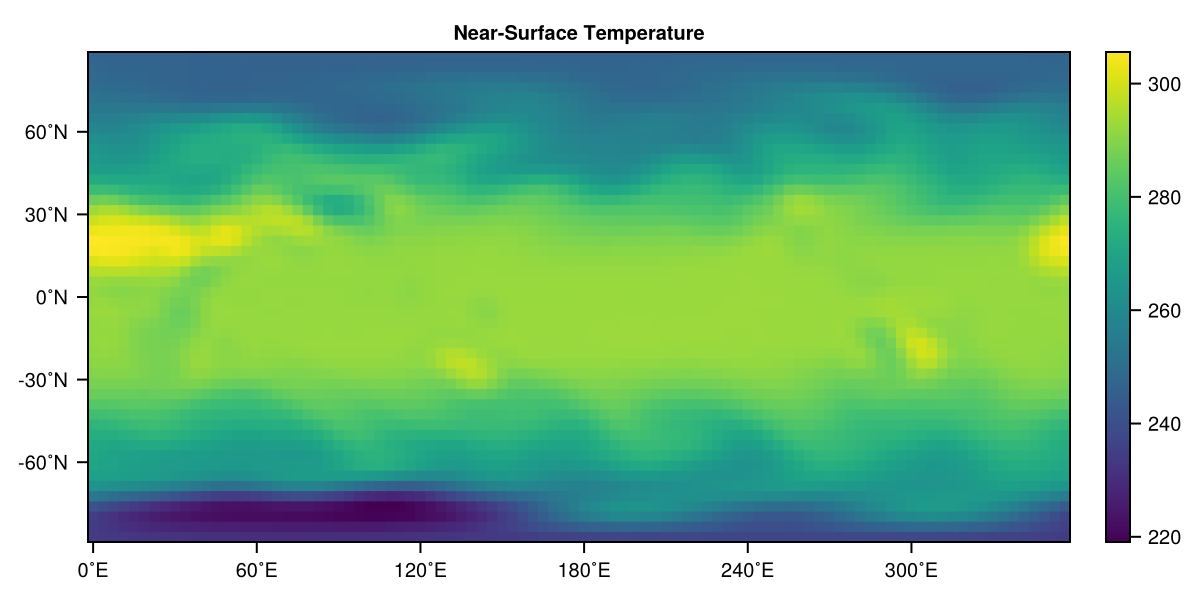

In [ ]:
using Statistics

# spectral_grid = SpectralGrid(trunc=31, nlayers=8)
spectral_grid = SpectralGrid()
model = PrimitiveWetModel(spectral_grid)
sim = initialize!(model)

run!(sim, period=Day(100))

println("Simulation complete!")


# variable
T = sim.diagnostic_variables.grid.temp_grid[:,end]

println("Temperature size: ", size(T))
println("Mean temperature: ", mean(T))

# Plot lowest atmospheric level

heatmap(
    # T[:,:,end],
    T,
    title="Near-Surface Temperature"
    #xlabel="Longitude",
    #ylabel="Latitude",
    #colorbar_title="T (K)"
)

In [ ]:

#Developer version
#Pkg.develop("SpeedyWeather")


# Define grid
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
# Define output. Change the id for the control run and the flat earth run
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="./", id="base_temp", output_dt=Minute(360))

model = PrimitiveWetModel(spectral_grid; output)

# simulation = initialize!(model)
sim = initialize!(model)

# Add output variables
add!(model, SpeedyWeather.OceanOutput()...)
add!(model, SpeedyWeather.LandOutput()...)
add!(model, SpeedyWeather.RadiationOutput()...)
add!(model, SpeedyWeather.PrecipitationOutput()...)
add!(model, SpeedyWeather.SurfaceFluxesOutput()...)
#This adds orography variable to output
add!(model, SpeedyWeather.BoundaryOutput()...)

# run!(sim, period=Day(100))
run!(sim, period=Day(100), output=true)
println("Simulation complete!")


 run_base_temp_0001 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:01:42 (2000-04-10, 230.80 years/day, 94 m/s, [-75, 33] ˚C)


Simulation complete!


# **Python - plotting**

In [ ]:
## python

!pip install cartopy
import cartopy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import os

import sys

In [ ]:
datadir='.'

# ds=xr.open_dataset(f'{datadir}/run_output.nc') /content/run_base_temp_0001
ds=xr.open_dataset(f'{datadir}/run_base_temp_0001/output.nc')
ds

<xarray.Dataset> Size: 495MB
Dimensions:         (time: 401, lat: 48, lon: 96, soil_layer: 2, layer: 8)
Coordinates:
  * time            (time) datetime64[ns] 3kB 2000-01-01 ... 2000-04-10
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * soil_layer      (soil_layer) int64 16B 1 2
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
Data variables: (12/32)
    snow_cond       (time, lat, lon) float32 7MB ...
    sma             (time, lat, lon) float32 7MB ...
    rain_conv       (time, lat, lon) float32 7MB ...
    sru             (time, lat, lon) float32 7MB ...
    rain_cond       (time, lat, lon) float32 7MB ...
    lsm             (lat, lon) float32 18kB ...
    ...              ...
    olr             (time, lat, lon) float32 7MB ...
    lru             (time, lat, lon) float32 7MB ...
    roff            (time, lat, lon) float32 7MB ...
    snow_cond_rate  (time, lat, lon) float32 7MB ...
    rain_conv_rate  (time, lat, lon) float32 7MB ...
    rain_cond_rate  (time, lat, lon) float32 7MB ...

In [ ]:
ds_flat=xr.open_dataset(f'{datadir}/run_base_temp_0001/output.nc')
ds_flat

<xarray.Dataset> Size: 495MB
Dimensions:         (time: 401, lat: 48, lon: 96, soil_layer: 2, layer: 8)
Coordinates:
  * time            (time) datetime64[ns] 3kB 2000-01-01 ... 2000-04-10
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * soil_layer      (soil_layer) int64 16B 1 2
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
Data variables: (12/32)
    snow_cond       (time, lat, lon) float32 7MB ...
    sma             (time, lat, lon) float32 7MB ...
    rain_conv       (time, lat, lon) float32 7MB ...
    sru             (time, lat, lon) float32 7MB ...
    rain_cond       (time, lat, lon) float32 7MB ...
    lsm             (lat, lon) float32 18kB ...
    ...              ...
    olr             (time, lat, lon) float32 7MB ...
    lru             (time, lat, lon) float32 7MB ...
    roff            (time, lat, lon) float32 7MB ...
    snow_cond_rate  (time, lat, lon) float32 7MB ...
    rain_conv_rate  (time, lat, lon) float32 7MB ...
    rain_cond_rate  (time, lat, lon) float32 7MB ...

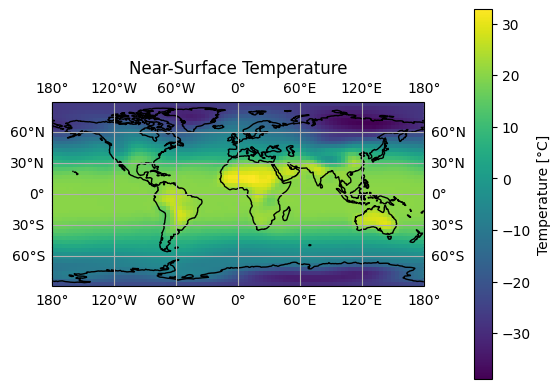

In [ ]:
ax=plt.axes(projection=ccrs.PlateCarree())

# T = ds.temp.isel(time=0, layer=0) #(layer = 0, top -- -1 = near surface)
Tmean = ds.temp.isel(layer=-1).mean(dim="time")

plt.pcolormesh(ds.lon,ds.lat,Tmean,transform=ccrs.PlateCarree())
cbar=plt.colorbar(pad=0.1)
cbar.set_label("Temperature [\N{DEGREE SIGN}C]")
ax.coastlines()

gl = ax.gridlines(draw_labels=True)
plt.title("Near-Surface Temperature")
plt.show()

# ax=plt.axes(projection=ccrs.PlateCarree())
# plt.pcolormesh(ds.lon,ds.lat,ds.orography,transform=ccrs.PlateCarree())
# cbar=plt.colorbar(orientation='horizontal', pad=0.04)
# cbar.set_label("Orography [m]")
# ax.coastlines()

In [ ]:
## calculate earth's average temperature

import numpy as np

# convert latitude to radians
weights = np.cos(np.deg2rad(ds.lat))

# normalize weights
weights = weights / weights.mean()

# apply weighting
Tglobal = (Tmean * weights).mean(dim=("lat", "lon"))

print(float(Tglobal) , '\N{DEGREE SIGN}C')

8.445679265505708 °C


**8.445679265505708 °C ~ 281.596 K**

The plotted figure represents the near-surface atmospheric temperature field produced by a global circulation simulation using SpeedyWeather.jl. The horizontal (x) axis corresponds to the Earth's longitude, while the vertical (y) axis corresponds to the Earth's latitude, representing positions from the South Pole to the North Pole. The temperature values shown in the color scale are expressed in Kelvin (K), with the simulated mean value (~282 K) which is physically reasonable for a global atmospheric average that includes colder high-latitude and upper-layer influences.

Each pixel in the heatmap represents the temperature at a specific grid point on Earth's surface layer, effectively providing a spatial snapshot of the atmospheric state after 100 days of model evolution. The large-scale structure in the plot is primarily governed by solar radiative forcing, where incoming solar energy is unevenly distributed due to Earth's curvature: regions near the equator receive more direct sunlight and thus exhibit higher temperatures, while higher latitudes receive less sunlight per unit area, resulting in cooler temperatures. This fundamental balance between incoming solar radiation and outgoing terrestrial radiation can be described by the radiative equilibrium relation:

$$(1−𝛼)\frac{S}{4}= 𝜎𝑇^{4} ,$$

where S is the solar constant, $\alpha$ is planetary albedo, and $\sigma$ is the Stefan-Boltzmann constant.

However, the temperature distribution is not perfectly zonally symmetric, indicating that the model is not purely radiative but also includes atmospheric dynamics such as fluid motion, heat transport, and instabilities. These processes redistribute energy through winds and circulation patterns, producing spatial variability beyond simple equator-to-pole gradients.

Overall, this baseline simulation represents a dynamically consistent climate state arising from the interaction of radiation, thermodynamics, and fluid dynamics. It serves as a reference configuration for investigating atmospheric sensitivity to solar forcing, where small perturbations in solar irradiance can be introduced to examine how the temperature field and more broadly, atmospheric circulation-responds.

# **2. Temperature Response to Solar Forcing (ΔT)**

**Spatial distribution of temperature change resulting from increased solar irradiance**

**Solar forcing is introduced by modifying the solar constant in the planetary configuration, which alters the incoming shortwave radiation in the model's radiative transfer scheme, thereby changing the atmospheric energy balance and driving temperature responses.**

-- Small perturbations (0.1 - 0.2%) in solar forcing allow the system to remain within a quasi-linear regime, where the temperature response scales proportionally with the forcing. Larger perturbations push the system into a nonlinear regime, where feedback processes dominate and the model may become unstable or physically unrealistic.

# **Julia**

In [ ]:
# Period = 365 days
# Solar Forcing = 0.1%

# --- Control simulation ---

# Define grid
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
# Define output. Change the id for the control run and the flat earth run
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="./", id="base_temp_365", output_dt=Minute(360))

model1 = PrimitiveWetModel(spectral_grid; output)

# simulation = initialize!(model)
sim1 = initialize!(model1)

# Add output variables
add!(model1, SpeedyWeather.OceanOutput()...)
add!(model1, SpeedyWeather.LandOutput()...)
add!(model1, SpeedyWeather.RadiationOutput()...)
add!(model1, SpeedyWeather.PrecipitationOutput()...)
add!(model1, SpeedyWeather.SurfaceFluxesOutput()...)
#This adds orography variable to output
add!(model1, SpeedyWeather.BoundaryOutput()...)

# run!(sim, period=Day(100))
run!(sim1, period=Day(365), output=true)
println("Simulation 1 year (base) complete!")


# --- Perturbed simulation ---

# Define output. Change the id for the control run and the flat earth run
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="./", id="pert_temp_365", output_dt=Minute(360))

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.001)  #  FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified, output)


# simulation = initialize!(model)
sim2 = initialize!(model2)

# Add output variables
add!(model2, SpeedyWeather.OceanOutput()...)
add!(model2, SpeedyWeather.LandOutput()...)
add!(model2, SpeedyWeather.RadiationOutput()...)
add!(model2, SpeedyWeather.PrecipitationOutput()...)
add!(model2, SpeedyWeather.SurfaceFluxesOutput()...)
#This adds orography variable to output
add!(model2, SpeedyWeather.BoundaryOutput()...)

# run!(sim, period=Day(100))
run!(sim2, period=Day(365), output=true)
println("Simulation 1 year (perturbed) complete!")


 run_base_temp_365_0001 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:06:09 (2000-12-31, 233.50 years/day, 82 m/s, [-78, 27] ˚C)


Simulation 1 year (base) complete!


 run_pert_temp_365_0001 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:06:12 (2000-12-31, 232.01 years/day, 79 m/s, [-76, 26] ˚C)


Simulation 1 year (perturbed) complete!


# **Python - plotting**

In [1]:
## python

!pip install cartopy
import cartopy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import os

import sys

In [27]:
datadir='.'

ds_b1=xr.open_dataset(f'{datadir}/run_base_temp_365_0001/output.nc')
ds_b1

# ds_flat=xr.open_dataset(f'{datadir}/run_base_temp_0001/output.nc')
# ds_flat


<xarray.Dataset> Size: 2GB
Dimensions:         (time: 1461, lat: 48, lon: 96, soil_layer: 2, layer: 8)
Coordinates:
  * time            (time) datetime64[ns] 12kB 2000-01-01 ... 2000-12-31
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * soil_layer      (soil_layer) int64 16B 1 2
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
Data variables: (12/32)
    snow_cond       (time, lat, lon) float32 27MB ...
    sma             (time, lat, lon) float32 27MB ...
    rain_conv       (time, lat, lon) float32 27MB ...
    sru             (time, lat, lon) float32 27MB ...
    rain_cond       (time, lat, lon) float32 27MB ...
    lsm             (lat, lon) float32 18kB ...
    ...              ...
    olr             (time, lat, lon) float32 27MB ...
    lru             (time, lat, lon) float32 27MB ...
    roff            (time, lat, lon) float32 27MB ...
    snow_cond_rate  (time, lat, lon) float32 27MB ...
    rain_conv_rate  (time, lat, lon) float32 27MB ...
    rain_cond_rate  (time, lat, lon) float32 27MB ...

In [28]:
ds_p1=xr.open_dataset(f'{datadir}/run_pert_temp_365_0001/output.nc')
ds_p1

<xarray.Dataset> Size: 2GB
Dimensions:         (time: 1461, lat: 48, lon: 96, soil_layer: 2, layer: 8)
Coordinates:
  * time            (time) datetime64[ns] 12kB 2000-01-01 ... 2000-12-31
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * soil_layer      (soil_layer) int64 16B 1 2
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
Data variables: (12/32)
    snow_cond       (time, lat, lon) float32 27MB ...
    sma             (time, lat, lon) float32 27MB ...
    rain_conv       (time, lat, lon) float32 27MB ...
    sru             (time, lat, lon) float32 27MB ...
    rain_cond       (time, lat, lon) float32 27MB ...
    lsm             (lat, lon) float32 18kB ...
    ...              ...
    olr             (time, lat, lon) float32 27MB ...
    lru             (time, lat, lon) float32 27MB ...
    roff            (time, lat, lon) float32 27MB ...
    snow_cond_rate  (time, lat, lon) float32 27MB ...
    rain_conv_rate  (time, lat, lon) float32 27MB ...
    rain_cond_rate  (time, lat, lon) float32 27MB ...

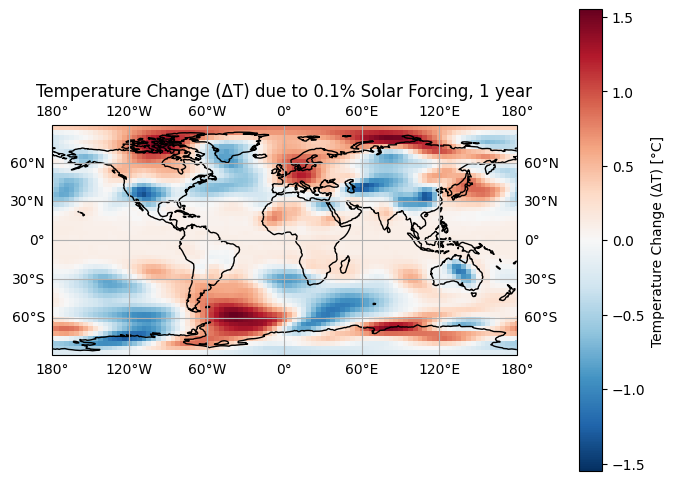

In [29]:
ax=plt.axes(projection=ccrs.PlateCarree())

# T = ds.temp.isel(time=0, layer=0) #(layer = 0, top -- -1 = near surface)
Tmean_b1 = ds_b1.temp.isel(layer=-1).mean(dim="time")
Tmean_p1 = ds_p1.temp.isel(layer=-1).mean(dim="time")

plt.pcolormesh(ds_b1.lon,ds_b1.lat,Tmean_p1-Tmean_b1,transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-np.max(Tmean_p1-Tmean_b1), vmax=np.max(Tmean_p1-Tmean_b1))
plt.rcParams["figure.figsize"] = (8, 6)

cbar=plt.colorbar(pad=0.1)
cbar.set_label("Temperature Change (ΔT) [\N{DEGREE SIGN}C]")
ax.coastlines()

gl = ax.gridlines(draw_labels=True)
plt.title("Temperature Change (ΔT) due to 0.1% Solar Forcing, 1 year")
plt.show()

# colormap = Reverse(:RdBu), colorrange = (minval, maxval)

The small (often near-zero) temperature change at the equator arises might be due to the tropical climate system is highly efficient at buffering and redistributing energy. Although the equator receives the most solar radiation, it is dominated by oceans with high heat capacity, meaning added energy is absorbed without producing large temperature increases (thermal inertia). At the same time, strong atmospheric circulation, particularly Hadley cells and deep convection, rapidly transports excess heat away from the equatorial region toward higher latitudes. In addition, abundant cloud cover in the tropics reflects a portion of incoming solar radiation, further limiting surface warming. Together, these processes prevent heat from accumulating locally, resulting in a relatively small temperature response despite increased solar forcing.

In [30]:
# Calculating climate sensitivity (lambda), 365 days, 0.1% solar forcing


# convert latitude to radians
weights = np.cos(np.deg2rad(ds_b1.lat))

# normalize weights
weights = weights / weights.mean()

Tmean1 = Tmean_p1-Tmean_b1

# apply weighting
Tglobal1 = (Tmean1 * weights).mean(dim=("lat", "lon"))



# --- Known value ---
S0 = 1361  # Earth default solar constant (W/m^2)

# --- Fractional change (0.1%) ---
fraction = 0.001

# --- Change in solar forcing ---
delta_S = (fraction * S0) / 4  # Earth is a sphere, incoming solar energy is averaged over the whole surface


# mean ΔT from the simulation
delta_T_mean = Tglobal1  # value in C

# --- Climate sensitivity ---
lambda_climate = delta_T_mean / delta_S

# --- Output ---
print("ΔS (W/m²):", delta_S)
print("ΔT_mean (K):", delta_T_mean.item())
print("Max ΔT: ", np.max(Tmean1).item())
print("Min ΔT: ", np.min(Tmean1).item())
print("Climate sensitivity λ (K per W/m²):", lambda_climate.item())



ΔS (W/m²): 0.34025
ΔT_mean (K): 0.03983986992749943
Max ΔT:  1.551750659942627
Min ΔT:  -1.3684873580932617
Climate sensitivity λ (K per W/m²): 0.11708999243938113


To investigate the atmospheric response to solar forcing, I performed two simulations using SpeedyWeather.jl: a baseline run and a perturbed run with a +0.1% increase in the solar constant. Both simulations were integrated over 365 days. From the resulting global mean temperature change, I estimated the climate sensitivity parameter as:

$$λ≈0.12$$

This is relatively low compared to typical equilibrium estimates (~0.1–1.0 K/(W/m²) as reported by the Intergovernmental Panel on Climate Change). This result is expected for a short simulation, as the climate system especially the ocean has not fully adjusted to the imposed forcing due to thermal inertia. Energy redistribution by atmospheric circulation further limits the immediate temperature response, particularly in equatorial regions. Despite this, the result is consistent with the lower range of expected climate sensitivity values, indicating that the model captures the correct physical behaviour. Longer simulations should allow the system to reach equilibrium and produce a more robust estimate.

# **Simulations for 2000 days, solar forcing 0.1%**

In [ ]:
# Period = 2000 days
# Solar Forcing = 0.1%

# --- Control simulation ---

# Define grid
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
# Define output. Change the id for the control run and the flat earth run
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="./", id="base_temp_2000_1", output_dt=Minute(360))

model1 = PrimitiveWetModel(spectral_grid; output)

# simulation = initialize!(model)
sim1 = initialize!(model1)

# Add output variables
add!(model1, SpeedyWeather.OceanOutput()...)
add!(model1, SpeedyWeather.LandOutput()...)
add!(model1, SpeedyWeather.RadiationOutput()...)
add!(model1, SpeedyWeather.PrecipitationOutput()...)
add!(model1, SpeedyWeather.SurfaceFluxesOutput()...)
#This adds orography variable to output
add!(model1, SpeedyWeather.BoundaryOutput()...)

# run!(sim, period=Day(100))
run!(sim1, period=Day(2000), output=true)
println("Simulation 5 year (base) complete!")


# --- Perturbed simulation ---

# Define output. Change the id for the control run and the flat earth run
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="./", id="pert_temp_2000_1", output_dt=Minute(360))

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.001)  #  FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified, output)


# simulation = initialize!(model)
sim2 = initialize!(model2)

# Add output variables
add!(model2, SpeedyWeather.OceanOutput()...)
add!(model2, SpeedyWeather.LandOutput()...)
add!(model2, SpeedyWeather.RadiationOutput()...)
add!(model2, SpeedyWeather.PrecipitationOutput()...)
add!(model2, SpeedyWeather.SurfaceFluxesOutput()...)
#This adds orography variable to output
add!(model2, SpeedyWeather.BoundaryOutput()...)

# run!(sim, period=Day(100))
run!(sim2, period=Day(2000), output=true)
println("Simulation 5 year (perturbed) complete!")


 run_base_temp_2000_1_0001 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:34:56 (2005-06-23, 225.82 years/day, 90 m/s, [-75, 28] ˚C)


Simulation 5 year (base) complete!


 run_pert_temp_2000_1_0001 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:34:53 (2005-06-23, 226.11 years/day, 79 m/s, [-78, 28] ˚C)


Simulation 5 year (perturbed) complete!


# **Python - plotting**

In [31]:
datadir='.'

ds_b1=xr.open_dataset(f'{datadir}/run_base_temp_2000_1_0001/output.nc')
ds_b1


<xarray.Dataset> Size: 10GB
Dimensions:         (time: 8001, lat: 48, lon: 96, soil_layer: 2, layer: 8)
Coordinates:
  * time            (time) datetime64[ns] 64kB 2000-01-01 ... 2005-06-23
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * soil_layer      (soil_layer) int64 16B 1 2
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
Data variables: (12/32)
    snow_cond       (time, lat, lon) float32 147MB ...
    sma             (time, lat, lon) float32 147MB ...
    rain_conv       (time, lat, lon) float32 147MB ...
    sru             (time, lat, lon) float32 147MB ...
    rain_cond       (time, lat, lon) float32 147MB ...
    lsm             (lat, lon) float32 18kB ...
    ...              ...
    olr             (time, lat, lon) float32 147MB ...
    lru             (time, lat, lon) float32 147MB ...
    roff            (time, lat, lon) float32 147MB ...
    snow_cond_rate  (time, lat, lon) float32 147MB ...
    rain_conv_rate  (time, lat, lon) float32 147MB ...
    rain_cond_rate  (time, lat, lon) float32 147MB ...

In [32]:
datadir='.'

ds_p1=xr.open_dataset(f'{datadir}/run_pert_temp_2000_1_0001/output.nc')
ds_p1



<xarray.Dataset> Size: 10GB
Dimensions:         (time: 8001, lat: 48, lon: 96, soil_layer: 2, layer: 8)
Coordinates:
  * time            (time) datetime64[ns] 64kB 2000-01-01 ... 2005-06-23
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * soil_layer      (soil_layer) int64 16B 1 2
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
Data variables: (12/32)
    snow_cond       (time, lat, lon) float32 147MB ...
    sma             (time, lat, lon) float32 147MB ...
    rain_conv       (time, lat, lon) float32 147MB ...
    sru             (time, lat, lon) float32 147MB ...
    rain_cond       (time, lat, lon) float32 147MB ...
    lsm             (lat, lon) float32 18kB ...
    ...              ...
    olr             (time, lat, lon) float32 147MB ...
    lru             (time, lat, lon) float32 147MB ...
    roff            (time, lat, lon) float32 147MB ...
    snow_cond_rate  (time, lat, lon) float32 147MB ...
    rain_conv_rate  (time, lat, lon) float32 147MB ...
    rain_cond_rate  (time, lat, lon) float32 147MB ...

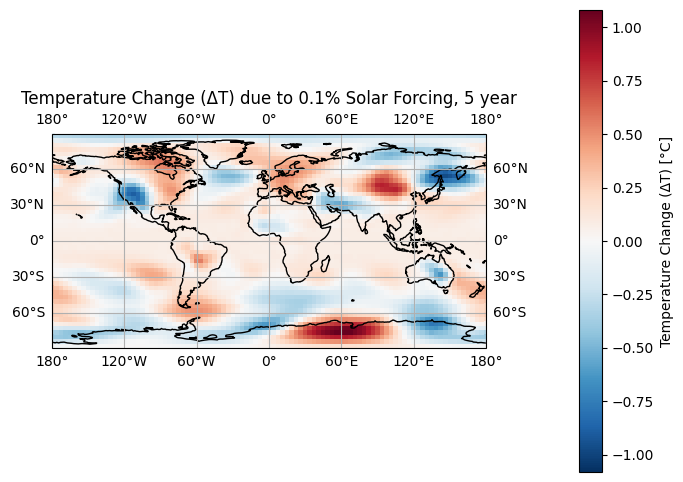

In [33]:
ax=plt.axes(projection=ccrs.PlateCarree())

# T = ds.temp.isel(time=0, layer=0) #(layer = 0, top -- -1 = near surface)
Tmean_b1 = ds_b1.temp.isel(layer=-1).mean(dim="time")
Tmean_p1 = ds_p1.temp.isel(layer=-1).mean(dim="time")

plt.pcolormesh(ds_b1.lon,ds_b1.lat,Tmean_p1-Tmean_b1,transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-np.max(Tmean_p1-Tmean_b1), vmax=np.max(Tmean_p1-Tmean_b1))
plt.rcParams["figure.figsize"] = (8, 6)

cbar=plt.colorbar(pad=0.15)
cbar.set_label("Temperature Change (ΔT) [\N{DEGREE SIGN}C]")
ax.coastlines()

gl = ax.gridlines(draw_labels=True)
plt.title("Temperature Change (ΔT) due to 0.1% Solar Forcing, 5 year")
plt.show()


In [34]:
# Calculating climate sensitivity (lambda), 2000 days, 0.1% solar forcing


# convert latitude to radians
weights = np.cos(np.deg2rad(ds_b1.lat))

# normalize weights
weights = weights / weights.mean()

Tmean1 = Tmean_p1-Tmean_b1

# apply weighting
Tglobal1 = (Tmean1 * weights).mean(dim=("lat", "lon"))



# --- Known value ---
S0 = 1361  # Earth default solar constant (W/m^2)

# --- Fractional change (0.1%) ---
fraction = 0.001

# --- Change in solar forcing ---
delta_S = (fraction * S0) / 4  # Earth is a sphere, incoming solar energy is averaged over the whole surface
# fraction * S0

# mean ΔT from the simulation
delta_T_mean = Tglobal1  # value in C

# --- Climate sensitivity ---
lambda_climate = delta_T_mean / delta_S

# --- Output ---
print("Temperature Change (ΔT) due to 0.1% Solar Forcing, 5 year - Output")
print("ΔS (W/m²):", delta_S)
print("ΔT_mean (K):", delta_T_mean.item())
print("Max ΔT: ", np.max(Tmean1).item())
print("Min ΔT: ", np.min(Tmean1).item())
print("Climate sensitivity λ (K per W/m²):", lambda_climate.item())



Temperature Change (ΔT) due to 0.1% Solar Forcing, 5 year - Output
ΔS (W/m²): 0.34025
ΔT_mean (K): 0.05011211544128011
Max ΔT:  1.0808029174804688
Min ΔT:  -0.9684085845947266
Climate sensitivity λ (K per W/m²): 0.1472802805033949


Extending the simulation period from 365 to 2000 days while maintaining a small solar forcing perturbation (0.1%) resulted in an increase in the estimated climate sensitivity from λ ≈ 0.12 to λ ≈ 0.15. This slight increase might reflects the transition from an initial transient atmospheric response to a more equilibrated state of the climate system.

The slab ocean component plays a particularly important role by absorbing excess energy, thereby damping atmospheric warming. Consequently, the lower sensitivity obtained in the 2000-day simulation represents a more stable, quasi-equilibrium response of the simplified climate model. However, due to the model's simplified radiative processes and absence of fully coupled ocean dynamics, this value likely underestimates the true Earth system climate sensitivity.

# **Simulations for 2000 days, solar forcing 0.2%**

In [ ]:
# Period = 2000 days
# Solar Forcing = 0.2%

# --- Control simulation ---

# Define grid
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
# Define output. Change the id for the control run and the flat earth run
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="./", id="base_temp_2000_2", output_dt=Minute(360))

model1 = PrimitiveWetModel(spectral_grid; output)

# simulation = initialize!(model)
sim1 = initialize!(model1)

# Add output variables
add!(model1, SpeedyWeather.OceanOutput()...)
add!(model1, SpeedyWeather.LandOutput()...)
add!(model1, SpeedyWeather.RadiationOutput()...)
add!(model1, SpeedyWeather.PrecipitationOutput()...)
add!(model1, SpeedyWeather.SurfaceFluxesOutput()...)
#This adds orography variable to output
add!(model1, SpeedyWeather.BoundaryOutput()...)

# run!(sim, period=Day(100))
run!(sim1, period=Day(2000), output=true)
println("Simulation 5 year (base) complete!")


# --- Perturbed simulation ---

# Define output. Change the id for the control run and the flat earth run
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="./", id="pert_temp_2000_2", output_dt=Minute(360))

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.002)  #  FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified, output)


# simulation = initialize!(model)
sim2 = initialize!(model2)

# Add output variables
add!(model2, SpeedyWeather.OceanOutput()...)
add!(model2, SpeedyWeather.LandOutput()...)
add!(model2, SpeedyWeather.RadiationOutput()...)
add!(model2, SpeedyWeather.PrecipitationOutput()...)
add!(model2, SpeedyWeather.SurfaceFluxesOutput()...)
#This adds orography variable to output
add!(model2, SpeedyWeather.BoundaryOutput()...)

# run!(sim, period=Day(100))
run!(sim2, period=Day(2000), output=true)
println("Simulation 5 year (perturbed) complete!")


 run_base_temp_2000_2_0001 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:35:47 (2005-06-23, 220.42 years/day, 90 m/s, [-75, 28] ˚C)


Simulation 5 year (base) complete!


 run_pert_temp_2000_2_0001 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:35:20 (2005-06-23, 223.28 years/day, 89 m/s, [-78, 30] ˚C)


Simulation 5 year (perturbed) complete!


# **Python - plotting**

In [35]:
datadir='.'

ds_b1=xr.open_dataset(f'{datadir}/run_base_temp_2000_2_0001/output.nc')
ds_b1


<xarray.Dataset> Size: 10GB
Dimensions:         (time: 8001, lat: 48, lon: 96, soil_layer: 2, layer: 8)
Coordinates:
  * time            (time) datetime64[ns] 64kB 2000-01-01 ... 2005-06-23
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * soil_layer      (soil_layer) int64 16B 1 2
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
Data variables: (12/32)
    snow_cond       (time, lat, lon) float32 147MB ...
    sma             (time, lat, lon) float32 147MB ...
    rain_conv       (time, lat, lon) float32 147MB ...
    sru             (time, lat, lon) float32 147MB ...
    rain_cond       (time, lat, lon) float32 147MB ...
    lsm             (lat, lon) float32 18kB ...
    ...              ...
    olr             (time, lat, lon) float32 147MB ...
    lru             (time, lat, lon) float32 147MB ...
    roff            (time, lat, lon) float32 147MB ...
    snow_cond_rate  (time, lat, lon) float32 147MB ...
    rain_conv_rate  (time, lat, lon) float32 147MB ...
    rain_cond_rate  (time, lat, lon) float32 147MB ...

In [36]:
datadir='.'

ds_p1=xr.open_dataset(f'{datadir}/run_pert_temp_2000_2_0001/output.nc')
ds_p1


<xarray.Dataset> Size: 10GB
Dimensions:         (time: 8001, lat: 48, lon: 96, soil_layer: 2, layer: 8)
Coordinates:
  * time            (time) datetime64[ns] 64kB 2000-01-01 ... 2005-06-23
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * soil_layer      (soil_layer) int64 16B 1 2
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
Data variables: (12/32)
    snow_cond       (time, lat, lon) float32 147MB ...
    sma             (time, lat, lon) float32 147MB ...
    rain_conv       (time, lat, lon) float32 147MB ...
    sru             (time, lat, lon) float32 147MB ...
    rain_cond       (time, lat, lon) float32 147MB ...
    lsm             (lat, lon) float32 18kB ...
    ...              ...
    olr             (time, lat, lon) float32 147MB ...
    lru             (time, lat, lon) float32 147MB ...
    roff            (time, lat, lon) float32 147MB ...
    snow_cond_rate  (time, lat, lon) float32 147MB ...
    rain_conv_rate  (time, lat, lon) float32 147MB ...
    rain_cond_rate  (time, lat, lon) float32 147MB ...

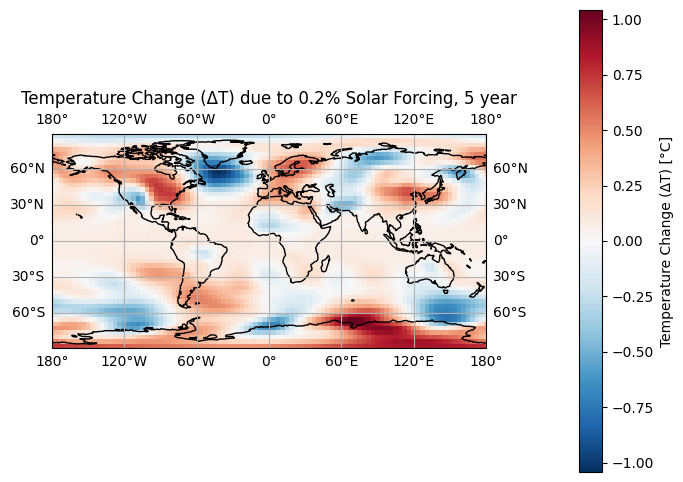

In [37]:
ax=plt.axes(projection=ccrs.PlateCarree())

# T = ds.temp.isel(time=0, layer=0) #(layer = 0, top -- -1 = near surface)
Tmean_b1 = ds_b1.temp.isel(layer=-1).mean(dim="time")
Tmean_p1 = ds_p1.temp.isel(layer=-1).mean(dim="time")

plt.pcolormesh(ds_b1.lon,ds_b1.lat,Tmean_p1-Tmean_b1,transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-np.max(Tmean_p1-Tmean_b1), vmax=np.max(Tmean_p1-Tmean_b1))
plt.rcParams["figure.figsize"] = (8, 6)

cbar=plt.colorbar(pad=0.15)
cbar.set_label("Temperature Change (ΔT) [\N{DEGREE SIGN}C]")
ax.coastlines()

gl = ax.gridlines(draw_labels=True)
plt.title("Temperature Change (ΔT) due to 0.2% Solar Forcing, 5 year")
plt.show()


In [38]:
# Calculating climate sensitivity (lambda), 2000 days, 0.2% solar forcing


# convert latitude to radians
weights = np.cos(np.deg2rad(ds_b1.lat))

# normalize weights
weights = weights / weights.mean()

Tmean1 = Tmean_p1-Tmean_b1

# apply weighting
Tglobal1 = (Tmean1 * weights).mean(dim=("lat", "lon"))



# --- Known value ---
S0 = 1361  # Earth default solar constant (W/m^2)

# --- Fractional change (0.1%) ---
fraction = 0.002

# --- Change in solar forcing ---
delta_S = (fraction * S0) / 4   # Earth is a sphere, incoming solar energy is averaged over the whole surface

# fraction * S0

# mean ΔT from the simulation
delta_T_mean = Tglobal1  # value in C

# --- Climate sensitivity ---
lambda_climate = delta_T_mean / delta_S

# --- Output ---
print("Temperature Change (ΔT) due to 0.2% Solar Forcing, 5 year - Output")
print("ΔS (W/m²):", delta_S)
print("ΔT_mean (K):", delta_T_mean.item())
print("Max ΔT: ", np.max(Tmean1).item())
print("Min ΔT: ", np.min(Tmean1).item())
print("Climate sensitivity λ (K per W/m²):", lambda_climate.item())



Temperature Change (ΔT) due to 0.2% Solar Forcing, 5 year - Output
ΔS (W/m²): 0.6805
ΔT_mean (K): 0.0725009240338701
Max ΔT:  1.0420169830322266
Min ΔT:  -1.0501232147216797
Climate sensitivity λ (K per W/m²): 0.10654066720627493


The decrease in estimated climate sensitivity (λ ≈ 0.15 to λ ≈ 0.11) with increasing solar forcing (0.1% to 0.2%) indicates a nonlinear response of the climate system. As forcing increases, enhanced radiative damping, atmospheric heat transport, and ocean heat uptake act to limit the temperature response, resulting in a lower effective sensitivity parameter.

-- Future work: plot λ vs solar forcing to see the changes in λ with different values of solar forcing

**The simulations were conducted using the PrimitiveWetModel in SpeedyWeather.jl, which solves the primitive equations for atmospheric dynamics and includes simplified representations of radiation, convection, and moisture processes. While this model captures the essential large-scale atmospheric response to solar forcing, it employs a slab ocean and simplified radiative transfer schemes, which limit its ability to fully represent long-term climate feedbacks. As a result, the estimated climate sensitivity (λ) is model-dependent response, lower than values obtained from more comprehensive Earth system models. Nevertheless, it provides a physically consistent first-order estimate of atmospheric sensitivity to solar forcing.**